In [1]:
# Add imports
import urllib
import networkx as nx
import io
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import json
import os
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import *

In [2]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 11286
  Edges: 125705


In [8]:
era_order_display = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)'
]


Scale-Free Network Analysis (Chapter 4)
Check if your network follows a power-law degree distribution:

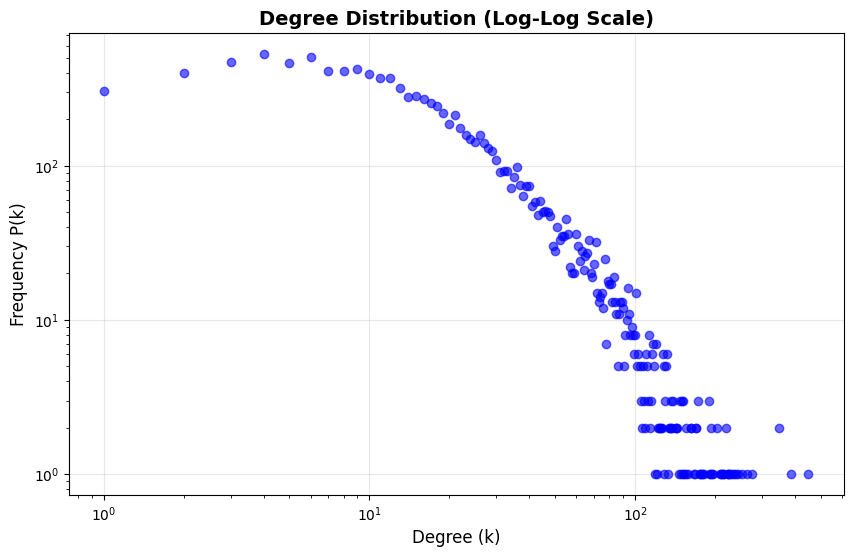

Power-law exponent (gamma): (np.float64(0.060909844997589904), np.float64(-2.2250738585072014e-308), np.float64(449.00000000000006))


/Users/denisa-student/.local/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:8786: RuntimeWarning: overflow encountered in divide
  return (shape - 1) * np.sum(1 / (loc - data))  # -1/(data-loc)
/opt/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [3]:
# Analyze degree distribution
degrees = [network.degree(node) for node in network.nodes()]
degree_counts = Counter(degrees)

# Plot on log-log scale
plt.figure(figsize=(10, 6))
x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]

plt.loglog(x, y, 'bo', alpha=0.6)
plt.xlabel('Degree (k)', fontsize=12)
plt.ylabel('Frequency P(k)', fontsize=12)
plt.title('Degree Distribution (Log-Log Scale)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate if it's scale-free
from scipy.stats import powerlaw
fit = powerlaw.fit(degrees)
print(f"Power-law exponent (gamma): {fit}")

 Assortativity (Chapter 7)
Analyze if influential people connect with other influential people:

In [9]:
# Group nodes by birth city
from collections import defaultdict

city_groups = defaultdict(list)

for node in network.nodes():
    birth_city = network.nodes[node].get('birthcity', 'Unknown')
    city_groups[birth_city].append(node)

# Print summary
print(f"Total unique birth cities: {len(city_groups)}\n")

# Show top 10 cities by number of people
sorted_cities = sorted(city_groups.items(), key=lambda x: len(x[1]), reverse=True)

print("Top 10 cities by number of people:")
for i, (city, people) in enumerate(sorted_cities[:10], 1):
    print(f"{i:2d}. {city:30s} - {len(people):4d} people")
    # Show first 3 people from this city
    for person in people[:3]:
        print(f"     - {person}")
    if len(people) > 3:
        print(f"     ... and {len(people) - 3} more")
    print()

Total unique birth cities: 5074

Top 10 cities by number of people:
 1. OTHER                          -  505 people
     - 37
     - 197
     - 451
     ... and 502 more

 2. NEW YORK                       -  338 people
     - 8844
     - 8845
     - 8846
     ... and 335 more

 3. PARIS                          -  244 people
     - 1631
     - 1642
     - 1669
     ... and 241 more

 4. LOS ANGELES                    -  190 people
     - 8691
     - 8692
     - 8693
     ... and 187 more

 5. LONDON                         -  177 people
     - 919
     - 944
     - 947
     ... and 174 more

 6. ROME                           -  170 people
     - 3954
     - 3973
     - 3977
     ... and 167 more

 7. CHICAGO                        -  107 people
     - 8729
     - 8730
     - 8732
     ... and 104 more

 8. MOSCOW                         -  104 people
     - 5927
     - 5930
     - 5935
     ... and 101 more

 9. ISTANBUL                       -   76 people
     - 1208
     - 7173
  

In [10]:
top_cities = sorted_cities[1:280]

print(f"Top 10 cities (total: {len(top_cities)})")
for i, (city, people) in enumerate(top_cities, 1):
    print(f"{i:2d}. {city:30s} - {len(people):4d} people")

Top 10 cities (total: 279)
 1. NEW YORK                       -  338 people
 2. PARIS                          -  244 people
 3. LOS ANGELES                    -  190 people
 4. LONDON                         -  177 people
 5. ROME                           -  170 people
 6. CHICAGO                        -  107 people
 7. MOSCOW                         -  104 people
 8. ISTANBUL                       -   76 people
 9. VIENNA                         -   74 people
10. BOSTON                         -   65 people
11. BERLIN                         -   63 people
12. SAN FRANCISCO-BAY AREA         -   62 people
13. SAINT PETERSBURG               -   52 people
14. FLORENCE                       -   50 people
15. BUENOS AIRES                   -   43 people
16. MADRID                         -   43 people
17. MUNICH                         -   42 people
18. BUDAPEST                       -   38 people
19. STOCKHOLM                      -   38 people
20. COPENHAGEN                     -   37 

In [12]:
def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

In [16]:
city_era_groups = {}

for city, people in top_cities:
    city_era_groups[city] = defaultdict(list)
    
    for person in people:
        birth_year = network.nodes[person].get('birthyear', None)
        era = get_era(birth_year)
        city_era_groups[city][era].append(person)

In [17]:
# Degree assortativity
assortativity = nx.degree_assortativity_coefficient(network)
print(f"Degree assortativity: {assortativity:.4f}")
# Positive = high-degree nodes connect to high-degree nodes
# Negative = high-degree nodes connect to low-degree nodes

# Occupation-based assortativity by era
for era in era_order_display:
    era_nodes = []
    for city, people in top_cities:
        if city in city_era_groups and era in city_era_groups[city]:
            era_nodes.extend(city_era_groups[city][era])
    
    if len(era_nodes) > 10:
        era_subgraph = network.subgraph(era_nodes)
        # Analyze mixing patterns by occupation
        occupations = {node: network.nodes[node].get('occupation', 'Unknown') 
                      for node in era_subgraph.nodes()}
        nx.set_node_attributes(era_subgraph, occupations, 'occupation')
        
        # Calculate mixing matrix
        occupation_types = set(occupations.values())
        print(f"\n{era}: {len(occupation_types)} different occupations")

Degree assortativity: 0.0631

Before Christ (< 30): 16 different occupations

Classical Era (30-476): 8 different occupations

Middle Ages (476-1450): 17 different occupations

Early Modern (1450-1760): 32 different occupations

Industrial Era (1760-1840): 35 different occupations

Wartime (1840-1945): 73 different occupations

Post-War (1945-2025): 67 different occupations


 Centrality Evolution Over Time (Chapter 2 & 10)
Track how different centrality measures change across eras:

In [18]:
# Calculate multiple centrality measures per era
centrality_evolution = []

for era in era_order_display:
    era_nodes = []
    for city, people in top_cities:
        if city in city_era_groups and era in city_era_groups[city]:
            era_nodes.extend(city_era_groups[city][era])
    
    if len(era_nodes) > 5:
        era_subgraph = network.subgraph(era_nodes)
        
        # Calculate centralities
        degree_cent = nx.degree_centrality(era_subgraph)
        between_cent = nx.betweenness_centrality(era_subgraph)
        close_cent = nx.closeness_centrality(era_subgraph)
        
        # Get top nodes by each measure
        top_degree = max(degree_cent.items(), key=lambda x: x[1])
        top_between = max(between_cent.items(), key=lambda x: x[1])
        top_close = max(close_cent.items(), key=lambda x: x[1])
        
        centrality_evolution.append({
            'era': era,
            'top_degree': network.nodes[top_degree[0]].get('Name'),
            'top_betweenness': network.nodes[top_between[0]].get('Name'),
            'top_closeness': network.nodes[top_close[0]].get('Name'),
            'avg_degree': sum(degree_cent.values())/len(degree_cent)
        })

df_cent = pd.DataFrame(centrality_evolution)
print(df_cent)

                          era           top_degree      top_betweenness  \
0        Before Christ (< 30)             Augustus             Tiberius   
1      Classical Era (30-476)      Marcus Aurelius      Marcus Aurelius   
2      Middle Ages (476-1450)          Charlemagne      Dante Alighieri   
3    Early Modern (1450-1760)  Louis XIV of France  Louis XIV of France   
4  Industrial Era (1760-1840)       Queen Victoria       Queen Victoria   
5         Wartime (1840-1945)        Frank Sinatra      John F. Kennedy   
6        Post-War (1945-2025)         Barack Obama         Lionel Messi   

         top_closeness  avg_degree  
0        Julius Caesar    0.068889  
1      Marcus Aurelius    0.052632  
2      Dante Alighieri    0.018634  
3  Louis XIV of France    0.022487  
4       Queen Victoria    0.017419  
5      John F. Kennedy    0.005014  
6         Barack Obama    0.006552  


Community Detection (Chapter 9)
Find natural communities beyond just cities:

In [25]:
# Louvain community detection
from networkx.algorithms import community

communities = community.greedy_modularity_communities(network)

print(f"Found {len(communities)} communities")

# Analyze top 5 communities
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5], 1):
    print(f"\nCommunity {i}: {len(comm)} members")
    
    # What occupations dominate this community?
    occupations = [network.nodes[node].get('occupation', 'Unknown') for node in comm]
    top_occupations = Counter(occupations).most_common(3)
    print(f"  Top occupations: {top_occupations}")
    
    # What cities dominate?
    cities = [network.nodes[node].get('birthcity', 'Unknown') for node in comm]
    top_cities = Counter(cities).most_common(3)
    print(f"  Top cities: {top_cities}")
    
    # Sample members
    sample_names = [network.nodes[node].get('Name') for node in list(comm)[:5]]
    print(f"  Sample: {sample_names}")

Found 306 communities

Community 1: 4000 members
  Top occupations: [('POLITICIAN', 816), ('WRITER', 741), ('RELIGIOUS FIGURE', 260)]
  Top cities: [('PARIS', 169), ('OTHER', 141), ('LONDON', 89)]
  Sample: ['Joséphine de Beauharnais', 'Marcus Annaeus Lucanus', 'Demosthenes', 'Caesarion', 'Noah Webster']

Community 2: 3382 members
  Top occupations: [('ACTOR', 1108), ('POLITICIAN', 843), ('SINGER', 379)]
  Top cities: [('NEW YORK', 239), ('LOS ANGELES', 158), ('OTHER', 76)]
  Sample: ['Robert Redford', 'SIR Richard Branson', 'Benjamin Netanyahu', 'Jane Fonda', 'Johnny Weissmuller']

Community 3: 1131 members
  Top occupations: [('SOCCER PLAYER', 1027), ('COACH', 73), ('REFEREE', 10)]
  Top cities: [('BUENOS AIRES', 23), ('RIO DE JANEIRO', 15), ('AMSTERDAM', 14)]
  Sample: ['José Mourinho', 'Phil Jones', 'Alberto Aquilani', 'Victor Nsofor Obinna', 'Nikola Žigić']

Community 4: 861 members
  Top occupations: [('POLITICIAN', 485), ('RELIGIOUS FIGURE', 229), ('WRITER', 38)]
  Top cities: [